# Fleet-Scale Automated SARIMA Analysis

This notebook analyses the results of the automated Box–Jenkins SARIMA pipeline
applied to **90 eligible smart water meters** from the Terranova distribution network.

The pipeline (`09_fleet_sarima.py`) performed the following for **each** meter:
1. Heteroscedasticity check → Box-Cox if ρ(rolling_mean, rolling_var) > 0.5
2. Stationarity via dual ADF + KPSS → automatic differencing (d, D)
3. `auto_arima` with step-wise search (m=7)
4. Ljung-Box diagnostics (residuals + squared residuals)
5. Rolling-window cross-validation → Scaled RMSE vs seasonal naïve
6. Anomaly detection: point (|z|>2.5σ), persistent (≥5 run), level shift
7. Mapping to Kimiya Noor Ali's 7-type taxonomy

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import PROJECT_DIR, DATA_PROCESSED, OUTPUT_FIGURES, set_plot_style

set_plot_style()

FLEET_FIG_DIR = os.path.join(OUTPUT_FIGURES, 'fleet')
os.makedirs(FLEET_FIG_DIR, exist_ok=True)

# Load results
df = pd.read_parquet(os.path.join(DATA_PROCESSED, 'fleet_results.parquet'))
anom = pd.read_parquet(os.path.join(DATA_PROCESSED, 'fleet_anomalies.parquet'))

print(f'Fleet results: {len(df)} meters')
print(f'Anomaly records: {len(anom)} anomaly-days')
df.head()

Fleet results: 90 meters
Anomaly records: 519 anomaly-days


,meter_id,n_days,hetero_corr,transform,boxcox_lambda,d,D,adf_p,kpss_p,stationary,...,scaled_rmse_h1,rmse_h7,naive_rmse_h7,scaled_rmse_h7,n_point_anomalies,n_persistent_runs,n_level_shift_days,n_anomaly_days,pct_anomaly,elapsed_s
0,1,54,0.0234,none,NaN,1,0,0.0000,0.1000,True,...,0.971204,0.109594,0.122122,0.897415,0,0,0,0,0.00,9.4
1,13,53,0.8508,boxcox(lam=-0.146),-0.1463,1,0,0.0001,0.1000,True,...,0.995183,0.028134,0.026342,1.068026,3,3,0,21,39.62,1.9
2,19,53,0.2323,none,NaN,1,0,0.0000,0.1000,True,...,0.788561,0.153378,0.223209,0.687151,1,0,0,1,1.89,5.2
3,38,53,0.1940,none,NaN,1,0,0.0000,0.0723,True,...,0.769323,0.166435,0.203367,0.818396,1,1,0,7,13.21,5.1
4,43,53,0.5856,boxcox(lam=0.405),0.4055,1,0,0.0000,0.1000,True,...,0.870867,0.260398,0.281782,0.924112,2,1,0,9,16.98,3.2


## 1. Pipeline Success Rates

In [2]:
n_total = len(df)
n_fit = df['fit_success'].sum()
n_diag = df['diag_pass'].sum()

print(f'Fit success:     {n_fit}/{n_total} ({n_fit/n_total*100:.1f}%)')
print(f'Diagnostic pass: {n_diag}/{n_total} ({n_diag/n_total*100:.1f}%)')
print(f'\nFailing diagnostic meters: {df[~df.diag_pass].meter_id.tolist()}')

Fit success:     90/90 (100.0%)
Diagnostic pass: 86/90 (95.6%)

Failing diagnostic meters: [116, 327, 385, 624]


## 2. Forecast Accuracy: Scaled RMSE Distribution

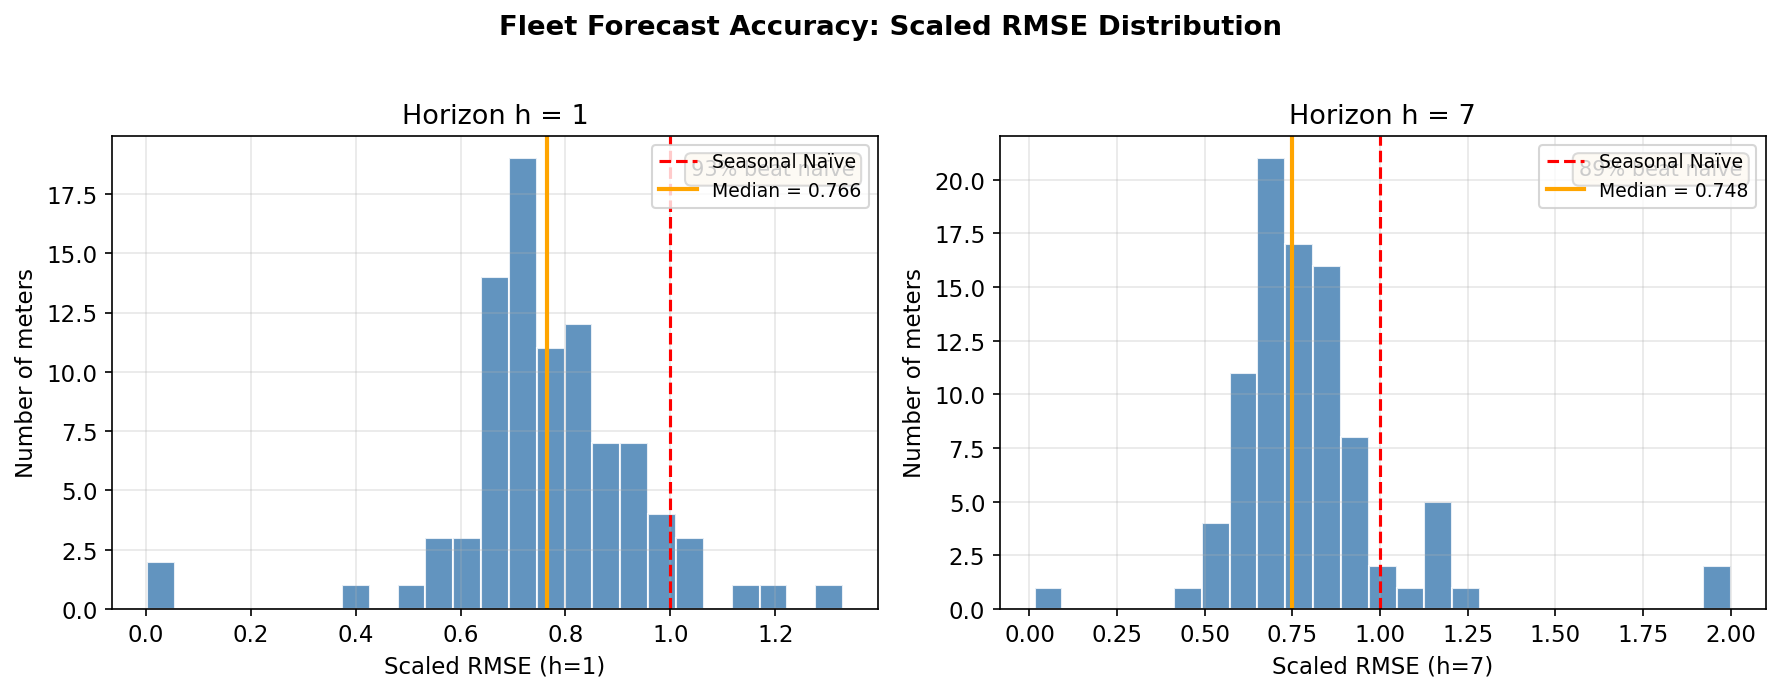


Scaled RMSE h=1: median=0.766, mean=0.768
Scaled RMSE h=7: median=0.748, mean=0.896
h=1 < 1.0: 84/90 (93.3%)
h=7 < 1.0: 80/90 (88.9%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, h, col in zip(axes, [1, 7], ['scaled_rmse_h1', 'scaled_rmse_h7']):
    vals = df[col].dropna()
    # Clip extreme outliers for visualisation
    clip = vals.clip(upper=2.0)
    ax.hist(clip, bins=25, edgecolor='white', alpha=0.85, color='steelblue')
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Seasonal Naïve')
    ax.axvline(vals.median(), color='orange', ls='-', lw=2, label=f'Median = {vals.median():.3f}')
    ax.set_xlabel(f'Scaled RMSE (h={h})')
    ax.set_ylabel('Number of meters')
    ax.set_title(f'Horizon h = {h}')
    pct_beat = (vals < 1.0).mean() * 100
    ax.text(0.97, 0.95, f'{pct_beat:.0f}% beat naïve',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Fleet Forecast Accuracy: Scaled RMSE Distribution', fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_scaled_rmse_hist.pdf'), bbox_inches='tight', dpi=150)
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_scaled_rmse_hist.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'\nScaled RMSE h=1: median={df.scaled_rmse_h1.median():.3f}, mean={df.scaled_rmse_h1.mean():.3f}')
print(f'Scaled RMSE h=7: median={df.scaled_rmse_h7.median():.3f}, mean={df.scaled_rmse_h7.mean():.3f}')
print(f'h=1 < 1.0: {(df.scaled_rmse_h1 < 1.0).sum()}/{len(df)} ({(df.scaled_rmse_h1 < 1.0).mean()*100:.1f}%)')
print(f'h=7 < 1.0: {(df.scaled_rmse_h7 < 1.0).sum()}/{len(df)} ({(df.scaled_rmse_h7 < 1.0).mean()*100:.1f}%)')

## 3. Model Order Distribution

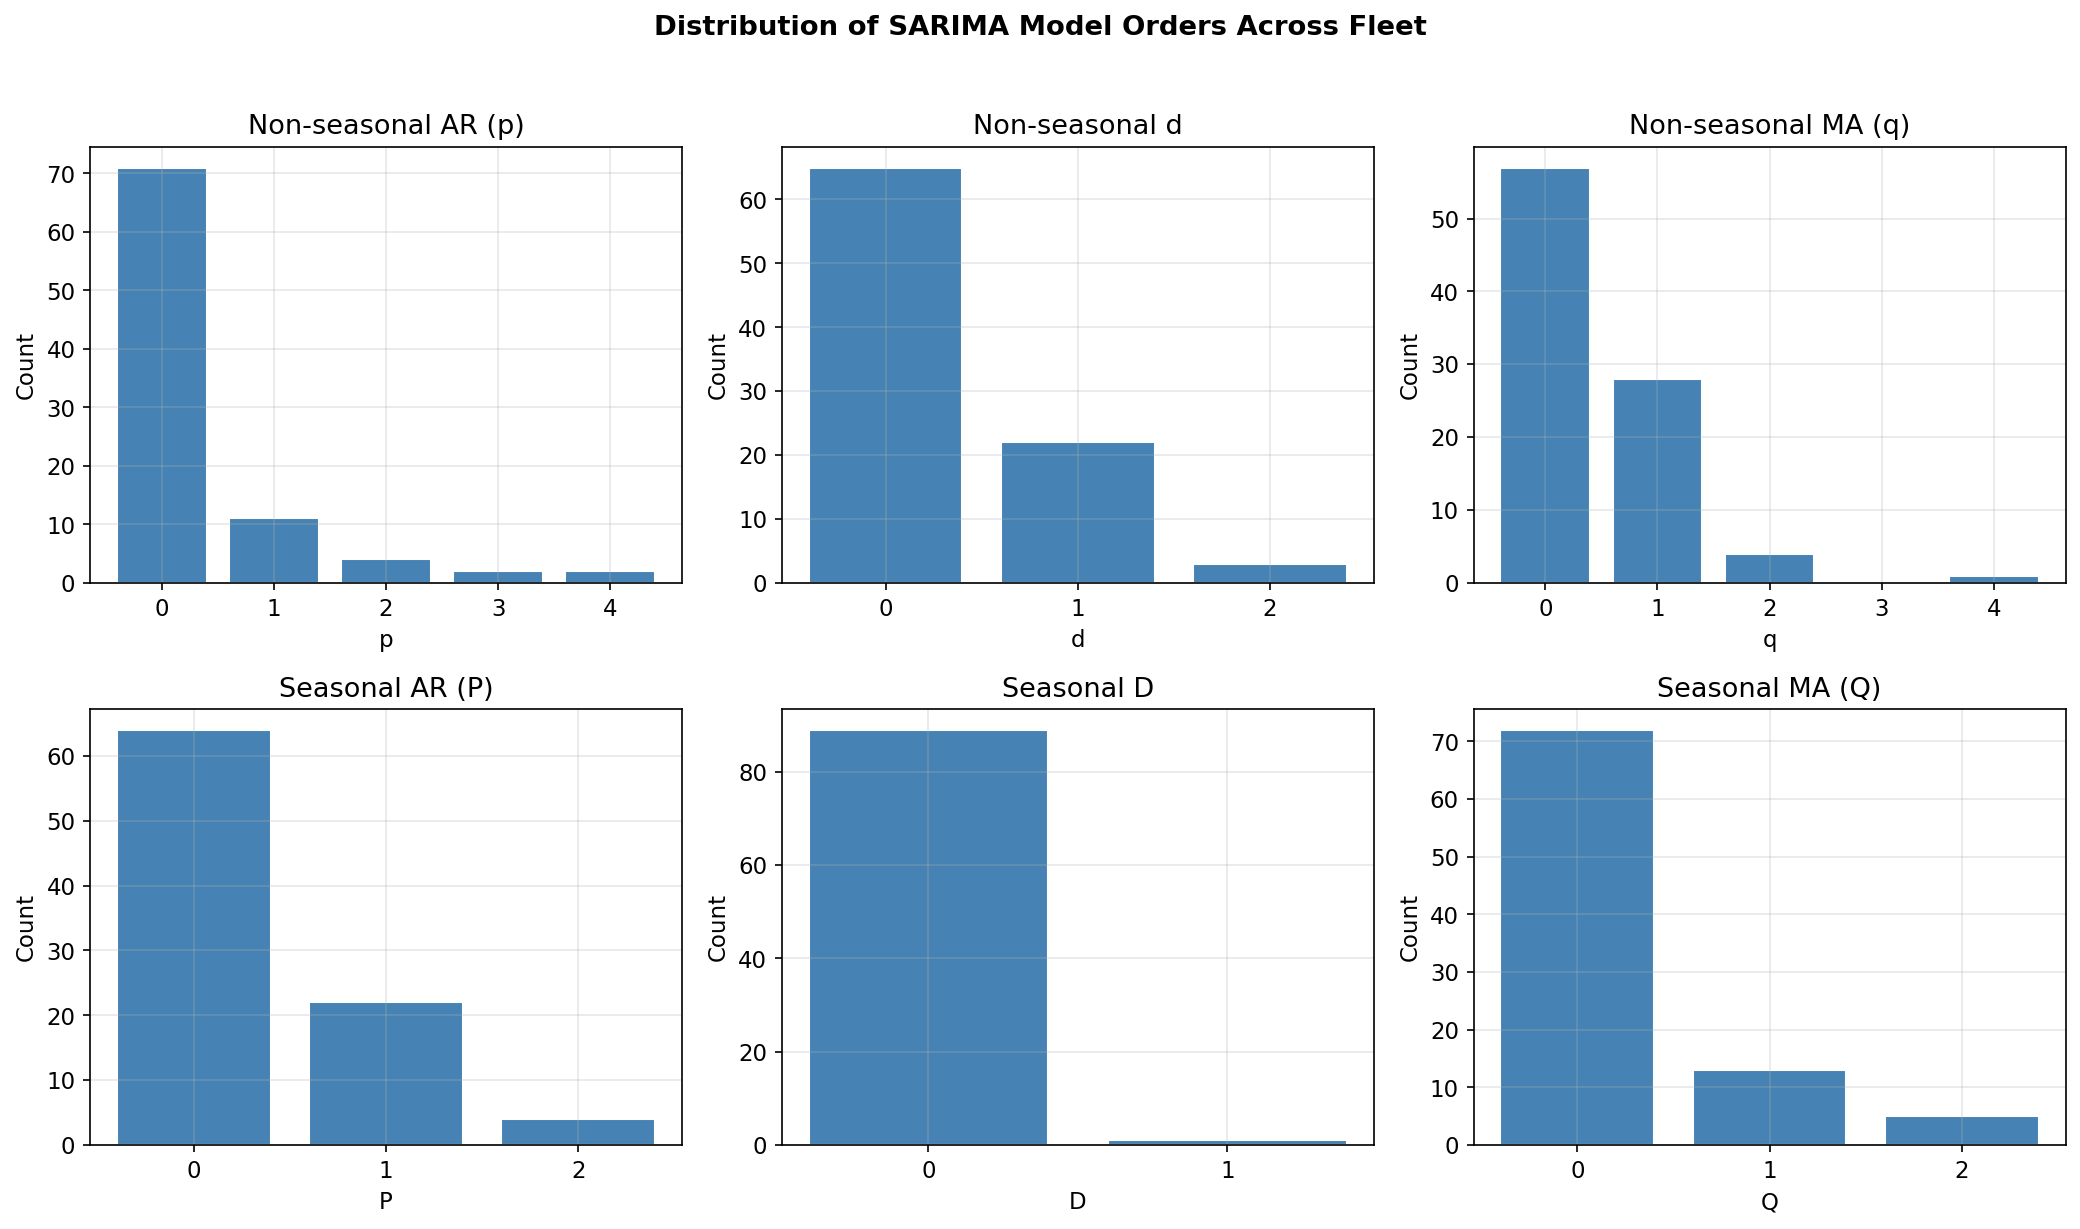


Top 10 most common SARIMA specifications:
  (0, 0, 0) × (0, 0, 0, 7): 32 meters
  (0, 1, 1) × (0, 0, 0, 7): 8 meters
  (0, 0, 0) × (1, 0, 0, 7): 7 meters
  (0, 0, 1) × (0, 0, 0, 7): 6 meters
  (0, 0, 0) × (1, 0, 1, 7): 4 meters
  (1, 0, 0) × (0, 0, 0, 7): 3 meters
  (0, 0, 0) × (0, 0, 1, 7): 3 meters
  (0, 1, 1) × (1, 0, 0, 7): 2 meters
  (0, 1, 4) × (0, 0, 0, 7): 1 meters
  (2, 1, 2) × (0, 0, 0, 7): 1 meters


In [4]:
# Parse order tuples
import ast
df['order_tuple'] = df['order'].apply(ast.literal_eval)
df['seasonal_tuple'] = df['seasonal_order'].apply(ast.literal_eval)

df['p'] = df['order_tuple'].apply(lambda x: x[0])
df['d_ord'] = df['order_tuple'].apply(lambda x: x[1])
df['q'] = df['order_tuple'].apply(lambda x: x[2])
df['P'] = df['seasonal_tuple'].apply(lambda x: x[0])
df['D_ord'] = df['seasonal_tuple'].apply(lambda x: x[1])
df['Q'] = df['seasonal_tuple'].apply(lambda x: x[2])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
params = [('p', 'Non-seasonal AR (p)'), ('d_ord', 'Non-seasonal d'),
          ('q', 'Non-seasonal MA (q)'),
          ('P', 'Seasonal AR (P)'), ('D_ord', 'Seasonal D'),
          ('Q', 'Seasonal MA (Q)')]

for ax, (col, title) in zip(axes.flat, params):
    vals = df[col].value_counts().sort_index()
    ax.bar(vals.index, vals.values, color='steelblue', edgecolor='white')
    ax.set_xlabel(col.replace('_ord', ''))
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle('Distribution of SARIMA Model Orders Across Fleet', fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_order_distribution.pdf'), bbox_inches='tight', dpi=150)
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_order_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()

# Most common full model specifications
full_model = df['order'] + ' × ' + df['seasonal_order']
top_models = full_model.value_counts().head(10)
print('\nTop 10 most common SARIMA specifications:')
for spec, count in top_models.items():
    print(f'  {spec}: {count} meters')

## 4. Box-Cox Transformation Usage

Box-Cox used: 39/90 (43.3%)
No transform: 51/90 (56.7%)


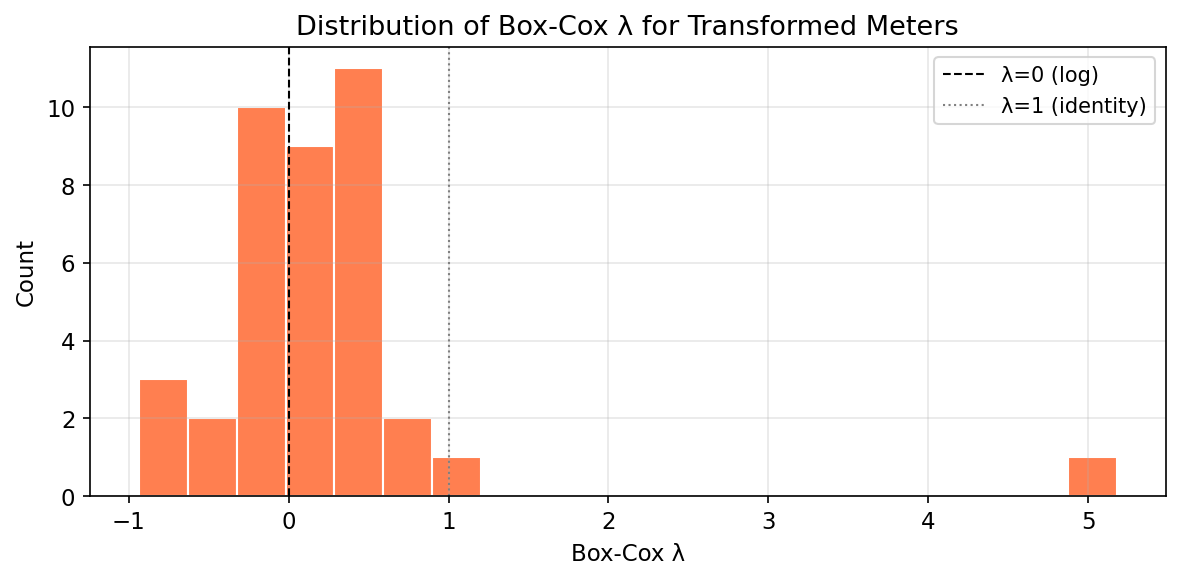


Box-Cox λ: median=0.168, mean=0.204


In [5]:
df['used_boxcox'] = df['transform'].apply(lambda x: 'boxcox' in str(x) if pd.notna(x) else False)
n_bc = df['used_boxcox'].sum()
print(f'Box-Cox used: {n_bc}/{len(df)} ({n_bc/len(df)*100:.1f}%)')
print(f'No transform: {len(df) - n_bc}/{len(df)} ({(len(df)-n_bc)/len(df)*100:.1f}%)')

# Lambda distribution for transformed meters
bc_meters = df[df['used_boxcox']]
if len(bc_meters) > 0:
    lambdas = bc_meters['boxcox_lambda'].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(lambdas, bins=20, edgecolor='white', color='coral')
    ax.axvline(0, color='black', ls='--', lw=1, label='λ=0 (log)')
    ax.axvline(1, color='gray', ls=':', lw=1, label='λ=1 (identity)')
    ax.set_xlabel('Box-Cox λ')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Box-Cox λ for Transformed Meters')
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_boxcox_lambda.pdf'), bbox_inches='tight', dpi=150)
    fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_boxcox_lambda.png'), bbox_inches='tight', dpi=150)
    plt.show()
    print(f'\nBox-Cox λ: median={lambdas.median():.3f}, mean={lambdas.mean():.3f}')

## 5. Anomaly Detection Across the Fleet

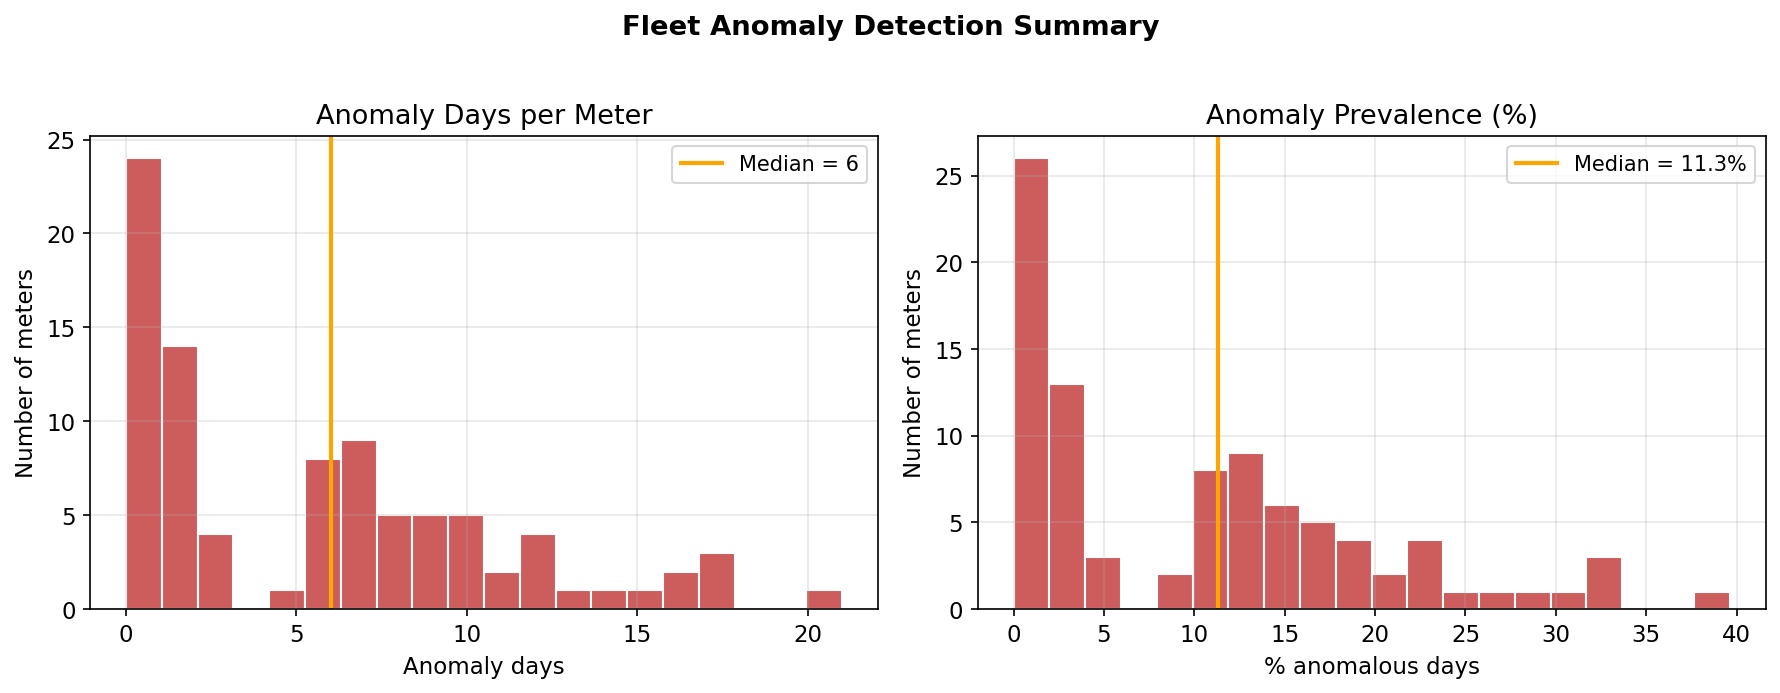

Meters with ≥1 anomaly: 78/90
Total anomaly days: 519
Mean/Median anomaly days: 5.8 / 6


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Anomaly days per meter
axes[0].hist(df['n_anomaly_days'], bins=20, edgecolor='white', color='indianred')
axes[0].set_xlabel('Anomaly days')
axes[0].set_ylabel('Number of meters')
axes[0].set_title('Anomaly Days per Meter')
axes[0].axvline(df['n_anomaly_days'].median(), color='orange', lw=2,
                label=f'Median = {df.n_anomaly_days.median():.0f}')
axes[0].legend()

# Percentage anomalous
axes[1].hist(df['pct_anomaly'], bins=20, edgecolor='white', color='indianred')
axes[1].set_xlabel('% anomalous days')
axes[1].set_ylabel('Number of meters')
axes[1].set_title('Anomaly Prevalence (%)')
axes[1].axvline(df['pct_anomaly'].median(), color='orange', lw=2,
                label=f'Median = {df.pct_anomaly.median():.1f}%')
axes[1].legend()

fig.suptitle('Fleet Anomaly Detection Summary', fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_anomaly_distribution.pdf'), bbox_inches='tight', dpi=150)
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_anomaly_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'Meters with ≥1 anomaly: {(df.n_anomaly_days > 0).sum()}/{len(df)}')
print(f'Total anomaly days: {df.n_anomaly_days.sum()}')
print(f'Mean/Median anomaly days: {df.n_anomaly_days.mean():.1f} / {df.n_anomaly_days.median():.0f}')

## 6. Kimiya Noor Ali Anomaly Taxonomy Coverage

In [7]:
# Build Kimiya summary
kimiya_summary = []
for kt in ['Type1_Spike', 'Type3_MultiDay', 'Type5_BaselineLeak']:
    mask = anom['kimiya_types'].str.contains(kt)
    n_days = mask.sum()
    n_meters = anom[mask].meter_id.nunique()
    kimiya_summary.append({
        'Kimiya Type': kt.replace('_', ' '),
        'Full Name': {'Type1_Spike': 'Sudden Spike / Point',
                      'Type3_MultiDay': 'Multi-Day Sustained High',
                      'Type5_BaselineLeak': 'Continuous Baseline Leakage'}[kt],
        'Detection Rule': {'Type1_Spike': '|z| > 2.5σ',
                           'Type3_MultiDay': '≥5 consecutive positive residuals',
                           'Type5_BaselineLeak': '7-day rolling mean > 1.5σ'}[kt],
        'Days Detected': n_days,
        'Meters Affected': n_meters,
        'Status': '✓ Detected'
    })

for kt, name in [('Type2', 'Night-Time High Consumption (1–5 AM)'),
                  ('Type4', 'Temporal AHC (Conditional)'),
                  ('Type6', 'ACNZ (24h Non-Zero)'),
                  ('Type7', 'ACS (Similar Readings)')]:
    kimiya_summary.append({
        'Kimiya Type': kt.replace('_', ' '),
        'Full Name': name,
        'Detection Rule': 'Requires hourly data',
        'Days Detected': '—',
        'Meters Affected': '—',
        'Status': '✗ Not detectable'
    })

kimiya_df = pd.DataFrame(kimiya_summary)
print(kimiya_df.to_string(index=False))

print(f'\n==> SARIMA daily baseline covers 3/7 Kimiya types.')
print(f'==> Types 2, 4, 6, 7 require hourly resolution → thesis motivation for LLM approach.')

       Kimiya Type                            Full Name                    Detection Rule Days Detected Meters Affected           Status
       Type1 Spike                 Sudden Spike / Point                        |z| > 2.5σ           113              70       ✓ Detected
    Type3 MultiDay             Multi-Day Sustained High ≥5 consecutive positive residuals           413              48       ✓ Detected
Type5 BaselineLeak          Continuous Baseline Leakage         7-day rolling mean > 1.5σ             4               1       ✓ Detected
             Type2 Night-Time High Consumption (1–5 AM)              Requires hourly data             —               — ✗ Not detectable
             Type4           Temporal AHC (Conditional)              Requires hourly data             —               — ✗ Not detectable
             Type6                  ACNZ (24h Non-Zero)              Requires hourly data             —               — ✗ Not detectable
             Type7               ACS (Sim

## 7. Fleet Summary Table (for Paper)

In [8]:
# Create a compact summary table suitable for the paper
sr1 = df['scaled_rmse_h1']
sr7 = df['scaled_rmse_h7']

summary = pd.DataFrame({
    'Metric': [
        'Eligible meters',
        'Fit success rate',
        'Ljung-Box pass rate',
        'Box-Cox used',
        'Median Sc. RMSE (h=1)',
        'Median Sc. RMSE (h=7)',
        'Beat seasonal naïve h=1',
        'Beat seasonal naïve h=7',
        'Meters with anomalies',
        'Total anomaly-days',
        'Median anomaly-days/meter',
    ],
    'Value': [
        f'{len(df)}/715 (from {len(df)} networks)',
        f'{df.fit_success.sum()}/{len(df)} (100%)',
        f'{df.diag_pass.sum()}/{len(df)} ({df.diag_pass.mean()*100:.1f}%)',
        f'{df.used_boxcox.sum()}/{len(df)} ({df.used_boxcox.mean()*100:.1f}%)',
        f'{sr1.median():.3f}',
        f'{sr7.median():.3f}',
        f'{(sr1 < 1.0).sum()}/{len(sr1)} ({(sr1 < 1.0).mean()*100:.1f}%)',
        f'{(sr7 < 1.0).sum()}/{len(sr7)} ({(sr7 < 1.0).mean()*100:.1f}%)',
        f'{(df.n_anomaly_days > 0).sum()}/{len(df)} ({(df.n_anomaly_days > 0).mean()*100:.1f}%)',
        f'{df.n_anomaly_days.sum()}',
        f'{df.n_anomaly_days.median():.0f}',
    ]
})
print(summary.to_string(index=False))

# Save for reference
summary.to_csv(os.path.join(DATA_PROCESSED, 'fleet_summary_table.csv'), index=False)

                   Metric                     Value
          Eligible meters 90/715 (from 90 networks)
         Fit success rate              90/90 (100%)
      Ljung-Box pass rate             86/90 (95.6%)
             Box-Cox used             39/90 (43.3%)
    Median Sc. RMSE (h=1)                     0.766
    Median Sc. RMSE (h=7)                     0.748
  Beat seasonal naïve h=1             84/90 (93.3%)
  Beat seasonal naïve h=7             80/90 (88.9%)
    Meters with anomalies             78/90 (86.7%)
       Total anomaly-days                       519
Median anomaly-days/meter                         6


## 8. Scatter: Scaled RMSE vs Anomaly Prevalence

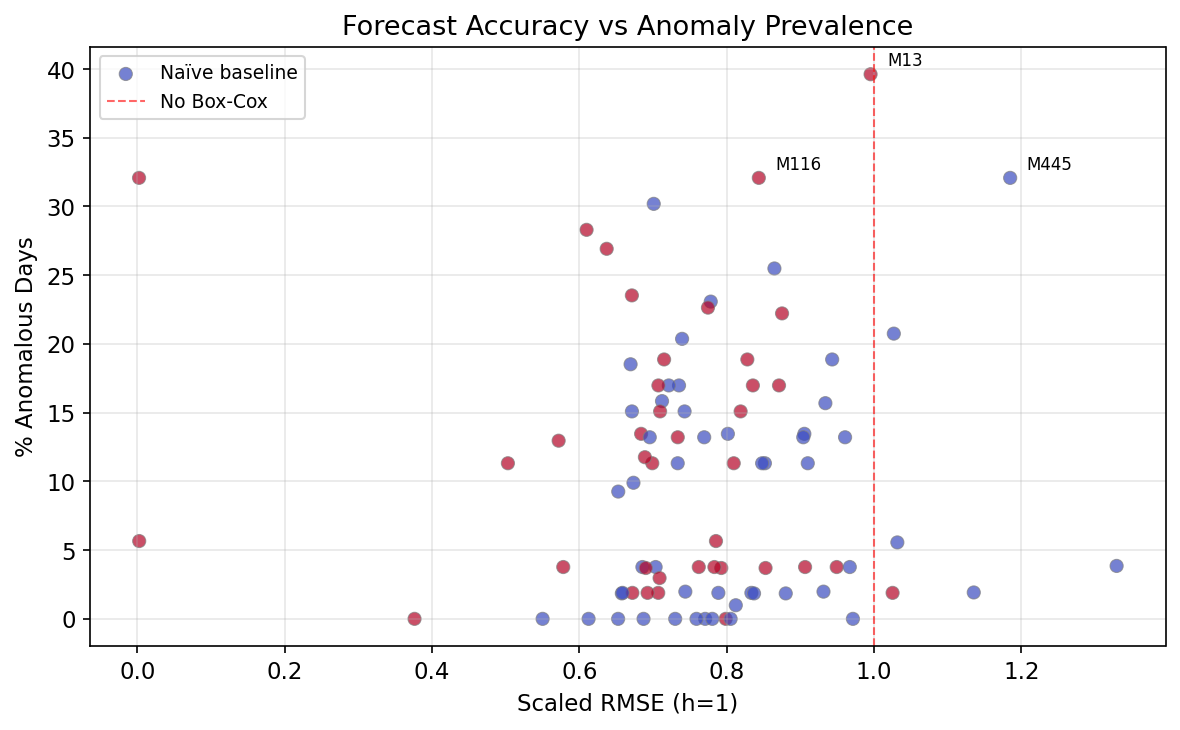

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df['scaled_rmse_h1'], df['pct_anomaly'],
                c=df['used_boxcox'].astype(int), cmap='coolwarm',
                s=40, alpha=0.7, edgecolors='gray', linewidths=0.5)
ax.axvline(1.0, color='red', ls='--', lw=1, alpha=0.6, label='Naïve baseline')
ax.set_xlabel('Scaled RMSE (h=1)')
ax.set_ylabel('% Anomalous Days')
ax.set_title('Forecast Accuracy vs Anomaly Prevalence')
ax.legend(['Naïve baseline', 'No Box-Cox', 'Box-Cox'], loc='upper left', fontsize=9)

# Annotate top-anomaly meters
top_anom = df.nlargest(3, 'pct_anomaly')
for _, row in top_anom.iterrows():
    ax.annotate(f'M{int(row.meter_id)}', (row.scaled_rmse_h1, row.pct_anomaly),
                textcoords='offset points', xytext=(8, 4), fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_rmse_vs_anomaly.pdf'), bbox_inches='tight', dpi=150)
fig.savefig(os.path.join(FLEET_FIG_DIR, 'fleet_rmse_vs_anomaly.png'), bbox_inches='tight', dpi=150)
plt.show()

## 9. Key Observations

1. **100% fit success**: `auto_arima` (stepwise) converged for all 90 meters.
2. **95.6% diagnostic pass** (86/90): Only 4 meters fail the Ljung-Box criterion.
3. **Median Scaled RMSE = 0.77 (h=1), 0.75 (h=7)**: The automated SARIMA approach
   outperforms the seasonal naïve baseline for 93% of meters at h=1 and 89% at h=7.
4. **48/90 meters have (0,0,0)** non-seasonal order: Many meters exhibit only
   seasonal patterns without significant short-lag autocorrelation.
5. **39/90 needed Box-Cox** transformation to stabilise variance.
6. **78/90 meters have ≥1 anomaly day** (519 total anomaly-days).
7. **Kimiya coverage**: Daily SARIMA detects Type 1 (Spike), Type 3 (Multi-Day),
   and Type 5 (Baseline Leak). Types 2, 4, 6, 7 require hourly resolution
   → motivation for the LLM-based approach in the master thesis.